In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt

import numpy as np
import scipy as sp
from scipy import special as scisp
from scipy.integrate import solve_ivp
from scipy.interpolate import InterpolatedUnivariateSpline,CubicSpline
import scipy.integrate
import scipy.optimize
import multiprocessing
from tqdm import trange
from scipy.optimize import curve_fit
import matplotlib.cm as cm
from matplotlib.gridspec import GridSpec
from scipy.interpolate import interp1d
from matplotlib.ticker import LogLocator, NullFormatter
import sys
from pathlib import Path
# add main_directory/ to the import path
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))
from source.SecludedDM import Cosmology, BaryonPortal, BoltzmannSolver, find_mXstar

plt.style.use('/home/gab/Desktop/PyCharm_env/mine.mplstyle')
plt.rcParams["axes.axisbelow"] = False

In [2]:
aXs_rs_str=['aX1e-03_r1.5','aX1e-03_r5.0','aX5e-03_r1.5','aX5e-03_r5.0']
aXs_rs_vals=np.array([[1e-3,1.5],[1e-3,5],[5e-3,1.5],[5e-3,5]])

In [3]:
def load_relic(fname):
    with open(fname) as f:
        params = dict(s.split('=') for s in f.readline().lstrip('# ').split())
    mXs, mYs, epsXs, epsXs_bbn = np.loadtxt(fname).T
    return {**{k: float(v) for k, v in params.items()},
            'mXs': mXs, 'mYs': mYs, 'epsXs': epsXs, 'epsXs_bbn': epsXs_bbn}
dats=[]
cosmo = Cosmology(gstar_choice="standard", gstarpath="./notebooks/")
for i in range(len(aXs_rs_str)):
    dat1 = load_relic("../output/bLP/relic_"+str(aXs_rs_str[i])+".dat")
    mXs1, mYs1, epsXs1, epsXs_bbn1 = dat1['mXs'],dat1['mYs'],dat1['epsXs'],dat1['epsXs_bbn']
    mXs1  = np.concatenate([[dat1['mXstar'], dat1['mXstar']*(1+1e-6)], mXs1])
    epsXs1 = np.concatenate([[1e-1, dat1['epsX_min']],    epsXs1])
    mXs_bbn_dd=np.logspace(np.log10(min([2,min(mXs1)])),np.log10(max(mXs1)),1000)
    bbn_bound=interp1d(mXs1[2:],epsXs_bbn1, kind="linear", fill_value="extrapolate", bounds_error=False)
    epsXs_bbn=bbn_bound(mXs_bbn_dd)
    epsXs_LZ=np.zeros(len(mXs_bbn_dd))
    epsXs_nu=np.zeros(len(mXs_bbn_dd))
    for j in trange(len(mXs_bbn_dd)):
        model = BaryonPortal(
            mX=mXs_bbn_dd[j],       
            mY=mXs_bbn_dd[j]/aXs_rs_vals[i][1],       
            alphaX=aXs_rs_vals[i][0]
        )
        solver = BoltzmannSolver(cosmo, model)
        try:
            epsXs_LZ[j]= solver.find_epsilon_DD(constraint='LZ',log10eps_range=(-9,0))
            epsXs_nu[j] = solver.find_epsilon_DD(constraint='nufloor_Xe',log10eps_range=(-9,0))
        except:
            continue
    Dict={'mXs':mXs1,'epsXs':epsXs1,'mXs_bbn_dd':mXs_bbn_dd,'epsXs_bbn':epsXs_bbn,'epsXs_LZ':epsXs_LZ,'epsXs_nu':epsXs_nu}
    dats.append(Dict)
    del Dict

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 6053.57it/s]


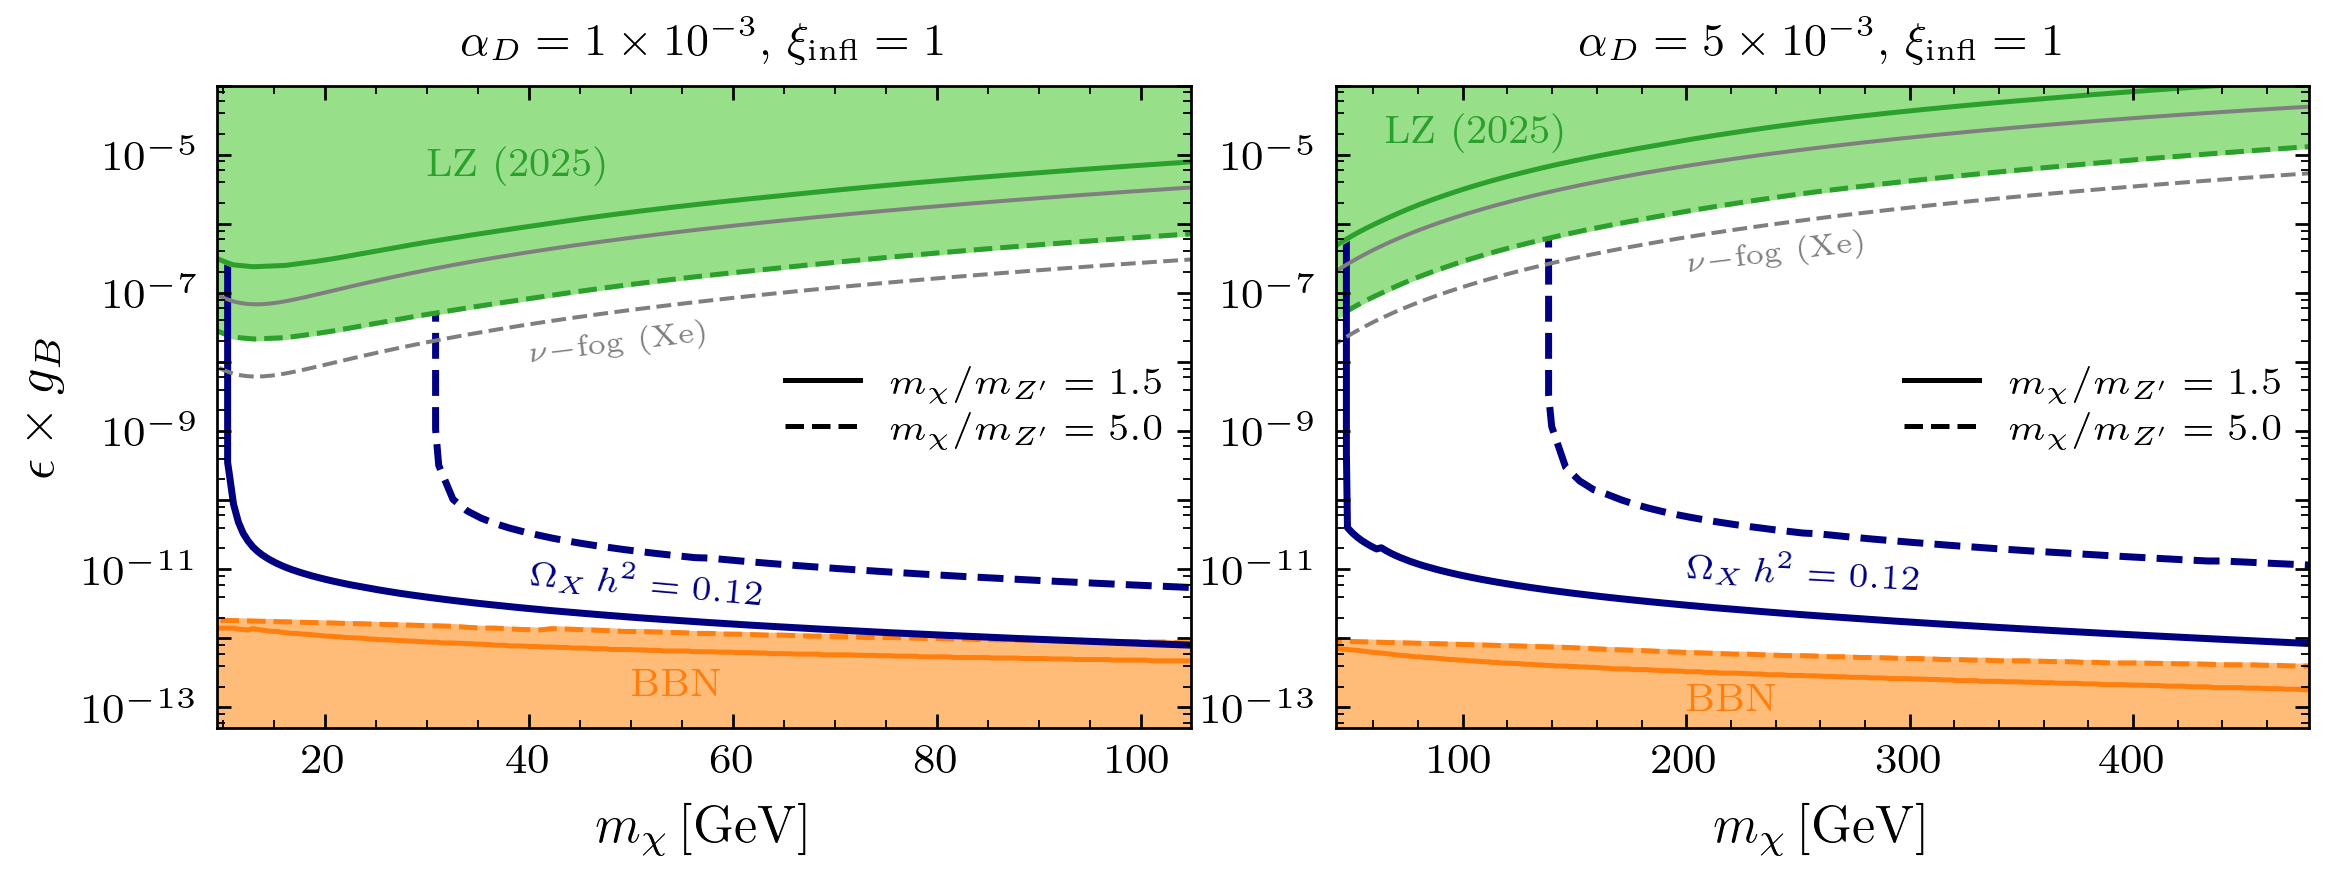

In [26]:
cs=plt.cm.tab20([0,1,2,3,4,5,6,7,8])
fig1=plt.figure(figsize=(7.5, 7.5/1.61803398875*0.5))
gs1 = GridSpec(20,17,figure=fig1)
ax1 = fig1.add_subplot(gs1[:,:8])
ax2 = fig1.add_subplot(gs1[:,9:])
lss=['-','--']
ZOs=[[-0.8,-.7],[-1,-0.9]]

for j in range(2):
    ax1.plot(dats[j]['mXs'],dats[j]['epsXs'],lw=1.4,c='navy',ls=lss[j],zorder=ZOs[j][0])
    ax1.fill_between(dats[j]['mXs_bbn_dd'],0, dats[j]['epsXs_bbn'],lw=1,color=cs[3],alpha=1,zorder=ZOs[j][1])
    ax1.plot(dats[j]['mXs_bbn_dd'],dats[j]['epsXs_bbn'],lw=1,color=cs[2],ls=lss[j],zorder=ZOs[j][1])
    ax1.fill_between(dats[j]['mXs_bbn_dd'],dats[j]['epsXs_LZ'],1,lw=1,color=cs[5],alpha=1,zorder=ZOs[j][1])
    ax1.plot(dats[j]['mXs_bbn_dd'],dats[j]['epsXs_LZ'],lw=1,color=cs[4],ls=lss[j],zorder=ZOs[j][1])
    ax1.plot(dats[j]['mXs_bbn_dd'],dats[j]['epsXs_nu'],lw=.8,c='tab:gray',ls=lss[j])
    ax2.plot(dats[2+j]['mXs'],dats[2+j]['epsXs'],lw=1.4,c='navy',ls=lss[j],zorder=ZOs[j][0])
    ax2.fill_between(dats[2+j]['mXs_bbn_dd'],0, dats[2+j]['epsXs_bbn'],lw=1,color=cs[3],alpha=1,zorder=ZOs[j][1])
    ax2.plot(dats[2+j]['mXs_bbn_dd'],dats[2+j]['epsXs_bbn'],lw=1,color=cs[2],ls=lss[j],zorder=ZOs[j][1])
    ax2.fill_between(dats[2+j]['mXs_bbn_dd'],dats[2+j]['epsXs_LZ'],1,lw=1,color=cs[5],alpha=1,zorder=ZOs[j][1])
    ax2.plot(dats[2+j]['mXs_bbn_dd'],dats[2+j]['epsXs_LZ'],lw=1,color=cs[4],ls=lss[j],zorder=ZOs[j][1])
    ax2.plot(dats[2+j]['mXs_bbn_dd'],dats[2+j]['epsXs_nu'],lw=.8,c='tab:gray',ls=lss[j])
ax1.set_ylabel(r"$\epsilon \times g_B$")
axs=[ax1,ax2]
for ax in axs:
    ax.set_yscale("log")
    ax.set_ylim(5e-14,1e-4)
    ax.set_yticks([1e-13,1e-12,1e-11,1e-10,1e-9,1e-8,1e-7,1e-6,1e-5,1e-4])
    ax.set_yticklabels(['$10^{-13}$','','$10^{-11}$','','$10^{-9}$','','$10^{-7}$','','$10^{-5}$',''])
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=[0.2, 0.4, 0.6, 0.8], numticks=200))
    ax.yaxis.set_minor_formatter(NullFormatter())
    ax.plot(np.NaN,np.NaN,ls='-',lw=1,c='k',label='$m_\chi/m_{Z^\prime}=1.5$')
    ax.plot(np.NaN,np.NaN,ls='--',lw=1,c='k',label='$m_\chi/m_{Z^\prime}=5.0$')
    ax.legend()
    ax.set_xlabel(r"$m_\chi\,[{\rm GeV}]$")
ax1.set_title(r'$\alpha_D=1\times 10^{-3},\,\xi_{\rm infl}=1$',fontsize=9)
ax2.set_title(r'$\alpha_D=5\times 10^{-3},\,\xi_{\rm infl}=1$',fontsize=9)
ax1.set_xlim(np.min(dats[0]['mXs'])*0.9,np.max(dats[0]['mXs']))
ax2.set_xlim(np.min(dats[2]['mXs'])*0.9,np.max(dats[2]['mXs']))
ax1.text(50,1.5e-13,r"BBN",color=cs[2],fontsize=8)
ax2.text(200,9e-14,r"BBN",color=cs[2],fontsize=8)
ax1.text(30,5e-6,r"LZ (2025)",color=cs[4], fontsize=8)
ax2.text(65,1.5e-5,r"LZ (2025)",color=cs[4], fontsize=8)
ax1.text(40,1e-8,r"$\nu-$fog (Xe)",color='tab:gray', fontsize=6, rotation=7)
ax1.text(40,3e-12,r"$\Omega_X\,h^2=0.12$",color='navy', fontsize=7, rotation=-5)
ax2.text(200,2e-7,r"$\nu-$fog (Xe)",color='tab:gray', fontsize=6, rotation=7)
ax2.text(200,5e-12,r"$\Omega_X\,h^2=0.12$",color='navy', fontsize=7, rotation=-3)
plt.savefig("../figs/bLP_aX1e-3_5e-3_r1.5_5.png")
plt.savefig("../figs/bLP_aX1e-3_5e-3_r1.5_5.png")
plt.show()
plt.close()